In [86]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statistics as stat
import seaborn as sns

%matplotlib notebook

In [87]:
F_file = "/home1/bhalla/hrishikeshn/Imaging_Sorted_for_Analysis/MatlabRun/G405/20210322/1/F_G405_20210322_plane1_proc.mat"

In [157]:
OUTPUT_PATH = "/home/bhalla/bhanups/work/hrishikeshn/"
CSV_PATH = "../../csv/"
IMAGING_PATH = "/home1/bhalla/hrishikeshn/Imaging_Sorted_for_Analysis/MatlabRun/"
animals = ["G405", "G396"]# ,"G394", 
protocol_info = {
                "SoAn1" : "250ms",
                "An1"   : "350ms",
                "An2"   : "450ms",
                "An3"   : "550ms",
                "Hr7"   : "250ms|550ms",
                "All3"  : "extinction",
                "All1"  : "acclimation",
                "Hr6"   : "250ms"
                }
timing_protocols = ["SoAn1", "An1", "An2", "An3"]
colors = sns.color_palette("colorblind", len(protocol_info))
colors[-1] = colors[0] # Setting Hr6 to have the same color as SoAn1
color_dict = dict(zip(protocol_info.keys(), colors))

In [153]:
def read_matlab_imaging_data(filename):
    data_mat = scipy.io.loadmat(filename)
    data = data_mat["dat"][0][0][0][0][0]
    data = np.reshape(data, (data.shape[0], int(data.shape[1]/232), 232))
    return data


In [104]:
def calc_dfbf(data, percentile):
    baselines = np.percentile(data, percentile, axis=-1)
    baselines = np.expand_dims(baselines, axis=-1)
    dfbf = np.divide((data - baselines), baselines)
    return data

In [77]:
def reshape_data_3D_to_2D(data_3D):
    data_2D = np.reshape(data_3D, (data_3D.shape[0], data_3D.shape[1]*data_3D.shape[2])).T
    return data_2D

In [223]:
def perform_PCA(x):
    x = StandardScaler().fit_transform(x)
    pca = PCA()
    principalComponents = pca.fit_transform(x)

    #Plot datapoints as scatter
#     fig = plt.figure(figsize = (4,4))
    
#     PC_values = np.arange(pca.n_components_) + 1
#     plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
#     plt.title('Scree Plot')
#     plt.xlabel('Principal Component')
#     plt.ylabel('Variance Explained')
#     plt.show()
    
    return pca.explained_variance_ratio_
    
#     ax.set_xlabel('PC1', fontsize = 15)
#     ax.set_ylabel('PC2', fontsize = 15)
#     ax.set_zlabel('PC3', fontsize = 15)
#     ax.set_title('Scatter plot traces', fontsize = 20)
#     targets = [0, 1]
#     colors = ['r', 'b']
#     stim = ["sound", "light"]
#     for target, color in zip(targets,colors):
#         indicesToKeep = finalDf['US_type'] == target
#         ax.scatter(finalDf.loc[indicesToKeep, 'PC1']
#                    , finalDf.loc[indicesToKeep, 'PC2']
#                    , finalDf.loc[indicesToKeep, 'PC3']
#                    , c = color
#                    , s = 50
#                    , alpha = 0.5
#                    , label=stim[target])
#     ax.legend()
#     ax.grid()
    
#     #Plot datapoints as traces
#     num_frames = np.int(x.shape[0] / num_trials)
#     fig2 = plt.figure(figsize = (8,8))
#     ax2 = fig2.add_subplot(projection='3d')
    
#     ax2.set_xlabel('PC1', fontsize = 15)
#     ax2.set_ylabel('PC2', fontsize = 15)
#     ax2.set_zlabel('PC3', fontsize = 15)
#     ax2.set_title('Line plot of traces', fontsize = 20)
#     targets = [0, 1]
        
  
#     for t_num in range(num_trials):
#         color = colors[stat.mode(y[t_num*num_frames:(t_num+1)*num_frames])]
#         ax2.plot(finalDf.loc[t_num*num_frames:(t_num+1)*num_frames, 'PC1']
#                    , finalDf.loc[t_num*num_frames:(t_num+1)*num_frames, 'PC2']
#                    , finalDf.loc[t_num*num_frames:(t_num+1)*num_frames, 'PC3']
#                    , c = color
#                    , alpha = 0.5)
#     ax2.grid()

In [226]:
num_components_to_reach_50 = {k:[] for k in animals}
num_cells = {k:[] for k in animals}
for animal in animals:
    csv_data = pd.read_csv(f"{CSV_PATH}/{animal}.csv")
    for upi in csv_data.loc[csv_data.behaviour_code=="SoAn1"].upi:
        csv_error_trials = set()
        if pd.notna(csv_data.loc[csv_data.upi==upi].skip_imaging_trials.iloc[0]):
            csv_error_trials.update(
                [int(x) for x in csv_data.loc[csv_data.upi==upi].skip_imaging_trials.iloc[0].split(";")]
            )
        if pd.notna(csv_data.loc[csv_data.upi==upi].missing_imaging_trials.iloc[0]):
            csv_error_trials.update(
                [int(x) for x in csv_data.loc[csv_data.upi==upi].missing_imaging_trials.iloc[0].split(";")]
            )
        
        filename = f"{IMAGING_PATH}/{animal}/{csv_data.loc[csv_data.upi==upi].date.iloc[0]}/1/F_{animal}_{csv_data.loc[csv_data.upi==upi].date.iloc[0]}_plane1_proc.mat"
        data = read_matlab_imaging_data(filename)
        if len(csv_error_trials) > 0:
            data = np.delete(data, np.array(list(csv_error_trials))-1, axis=1)
        dfbf = calc_dfbf(data, 10)
        reshaped_dfbf = reshape_data_3D_to_2D(dfbf)
        explained_variance = perform_PCA(reshaped_dfbf)
        num_components_to_reach_50[animal].append(np.where(np.cumsum(explained_variance)>0.5)[0][0])
        num_cells[animal].append(data.shape[0])
print(num_components_to_reach_50)
print(num_cells)



{'G405': [8, 8, 9, 1, 3, 5, 6, 3, 6], 'G396': [10, 3, 0, 1, 0, 1, 1]}
{'G405': [82, 71, 77, 61, 69, 66, 61, 64, 78], 'G396': [70, 70, 54, 61, 49, 61, 83]}


<IPython.core.display.Javascript object>


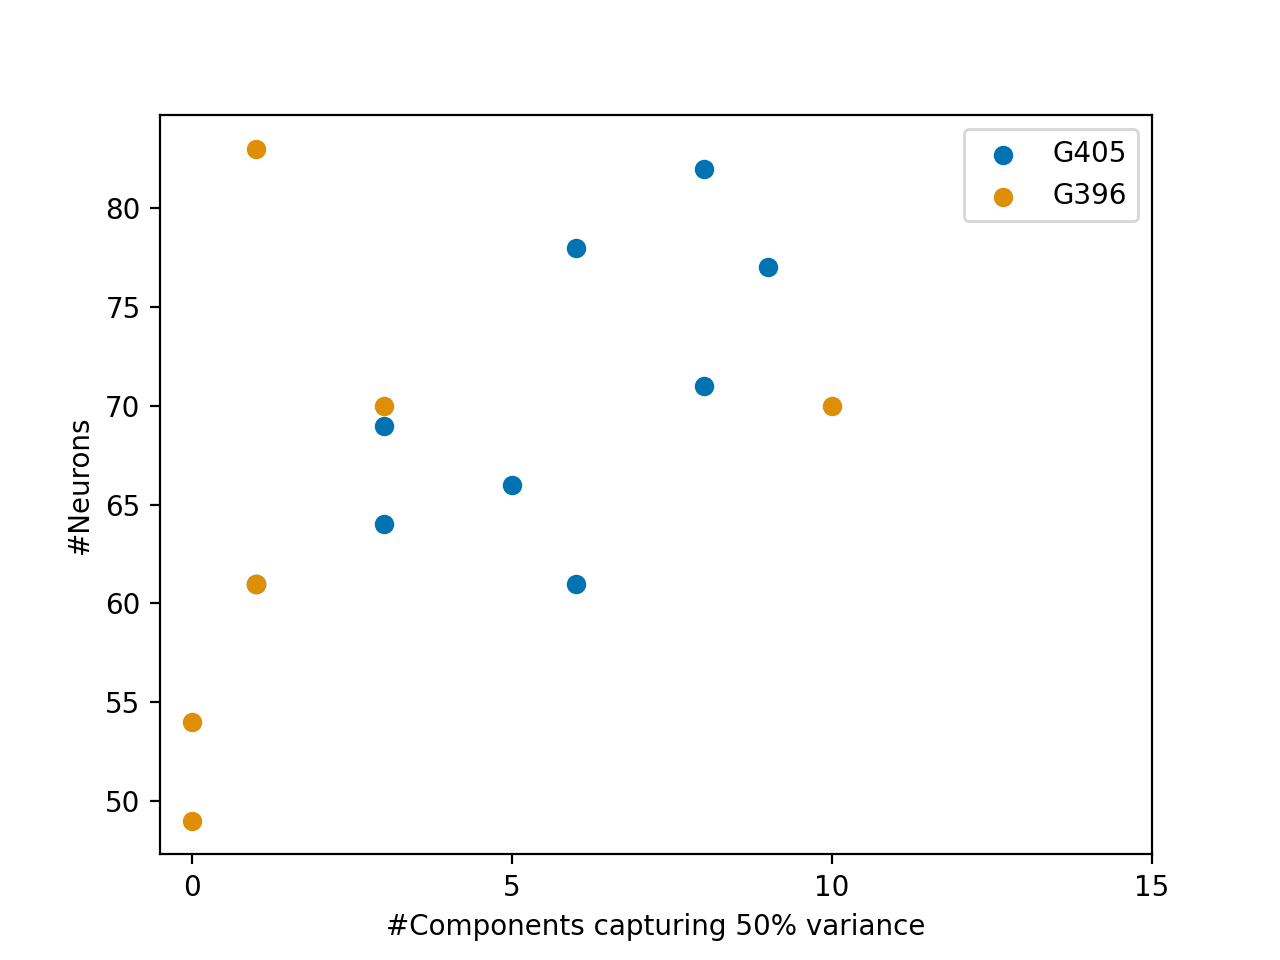

In [229]:
fig = plt.figure()
for a, animal in enumerate(animals):
    plt.scatter(num_components_to_reach_50[animal], num_cells[animal], color=colors[a], label=animal)
    plt.xlabel("#Components capturing 50% variance")
    plt.xticks(np.arange(0,20,5))
    plt.ylabel("#Neurons")
    plt.legend()
    plt.savefig(f"{OUTPUT_PATH}/compoenents_vs_neurons.png")
    
        

In [222]:
c = np.arange(24).reshape(2,3,4)

In [165]:
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [169]:
np.delete(c, 1, axis=1)

array([[[ 0,  1,  2,  3],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [20, 21, 22, 23]]])